In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [ ]:
# Load Dataset
df = pd.read_csv("https://raw.githubusercontent.com/YBIFoundation/ProjectHub-MachineLearning/main/Women%20Clothing%20E-Commerce%20Review.csv")

In [ ]:
# Display the first few rows of the dataframe
print(df.head())

   Clothing ID  Age                    Title  \
0          767   33                      NaN   
1         1080   34                      NaN   
2         1077   60  Some major design flaws   
3         1049   50         My favorite buy!   
4          847   47         Flattering shirt   

                                              Review  Rating  Recommended  \
0  Absolutely wonderful - silky and sexy and comf...       4            1   
1  Love this dress!  it's sooo pretty.  i happene...       5            1   
2  I had such high hopes for this dress and reall...       3            0   
3  I love, love, love this jumpsuit. it's fun, fl...       5            1   
4  This shirt is very flattering to all due to th...       5            1   

   Positive Feedback        Division Department   Category  
0                  0       Initmates   Intimate  Intimates  
1                  4         General    Dresses    Dresses  
2                  0         General    Dresses    Dresses  
3   

In [ ]:
# Information about the dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Clothing ID        23486 non-null  int64 
 1   Age                23486 non-null  int64 
 2   Title              19676 non-null  object
 3   Review             22641 non-null  object
 4   Rating             23486 non-null  int64 
 5   Recommended        23486 non-null  int64 
 6   Positive Feedback  23486 non-null  int64 
 7   Division           23472 non-null  object
 8   Department         23472 non-null  object
 9   Category           23472 non-null  object
dtypes: int64(5), object(5)
memory usage: 1.8+ MB
None


In [ ]:
# Check for missing values
print("Missing values in each column:\n", df.isna().sum())

Missing values in each column:
 Clothing ID             0
Age                     0
Title                3810
Review                845
Rating                  0
Recommended             0
Positive Feedback       0
Division               14
Department             14
Category               14
dtype: int64


In [ ]:

# Replace empty reviews with NaN and fill NaN values
df['Review'].replace("", np.NaN, inplace=True)
df['Review'].fillna("No review is given", inplace=True)

<ipython-input-40-e6ec2e5b401d>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Review'].replace("", np.NaN, inplace=True)
<ipython-input-40-e6ec2e5b401d>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [ ]:
# Check the cleaned reviews
print("After cleaning:\n", df['Review'].head())

After cleaning:
 0    Absolutely wonderful - silky and sexy and comf...
1    Love this dress!  it's sooo pretty.  i happene...
2    I had such high hopes for this dress and reall...
3    I love, love, love this jumpsuit. it's fun, fl...
4    This shirt is very flattering to all due to th...
Name: Review, dtype: object


<ipython-input-42-b31d2ed40992>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Rating', palette='viridis')


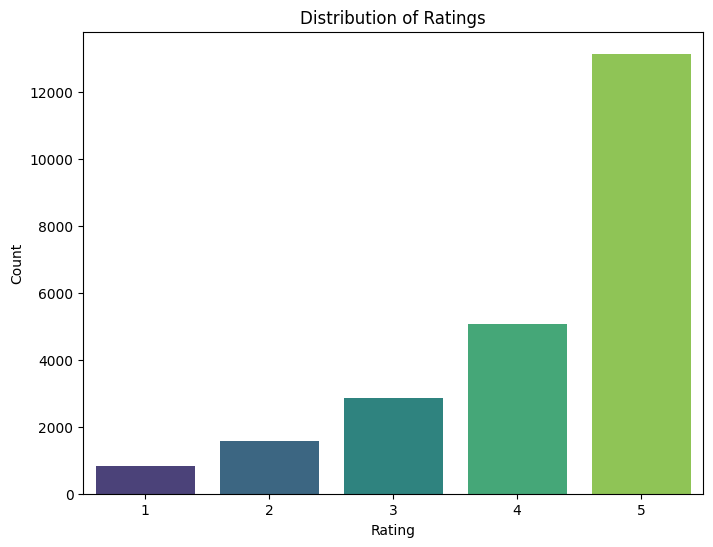

In [ ]:
# Review rating distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Rating', palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [ ]:

# Preparing data for modeling
# Group ratings into two categories: Positive (4, 5) and Negative (1, 2, 3)
df.replace({'Rating': {1: 0, 2: 0, 3: 0, 4: 1, 5: 1}}, inplace=True)
x = df['Review']
y = df['Rating']

In [ ]:
# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.7, stratify=y, random_state=2529)
print(f"x_train shape: {x_train.shape}, x_test shape: {x_test.shape}")

x_train shape: (16440,), x_test shape: (7046,)


In [ ]:
# Feature extraction using CountVectorizer
cv = CountVectorizer(lowercase=True, analyzer='word', ngram_range=(2, 3), stop_words='english', max_features=50000)
x_train = cv.fit_transform(x_train)
x_test = cv.transform(x_test)  # Use transform instead of fit_transform on test data



In [ ]:
# Train Naive Bayes model
model = MultinomialNB()
model.fit(x_train, y_train)

MultinomialNB()

In [ ]:
# Predict on test set
y_pred = model.predict(x_test)

In [ ]:
# Evaluate model performance
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

Confusion Matrix:
 [[ 894  689]
 [ 333 5130]]
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.56      0.64      1583
           1       0.88      0.94      0.91      5463

    accuracy                           0.85      7046
   macro avg       0.81      0.75      0.77      7046
weighted avg       0.85      0.85      0.85      7046

Accuracy: 0.8549531649162645


In [ ]:

# Hyperparameter tuning using GridSearchCV
param_grid = {'alpha': [0.1, 0.5, 1.0, 1.5]}
grid_search = GridSearchCV(MultinomialNB(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=MultinomialNB(),
             param_grid={'alpha': [0.1, 0.5, 1.0, 1.5]}, scoring='accuracy')

In [ ]:
print(f"Best parameters from GridSearch: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_}")

Best parameters from GridSearch: {'alpha': 1.5}
Best cross-validation score: 0.8436131386861314


In [ ]:

# Use the best model from grid search to predict
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(x_test)

In [ ]:
# Final evaluation with the best model
print("Best Model Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("Best Model Classification Report:\n", classification_report(y_test, y_pred_best))
print("Best Model Accuracy:", accuracy_score(y_test, y_pred_best))

Best Model Confusion Matrix:
 [[ 821  762]
 [ 247 5216]]
Best Model Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.52      0.62      1583
           1       0.87      0.95      0.91      5463

    accuracy                           0.86      7046
   macro avg       0.82      0.74      0.77      7046
weighted avg       0.85      0.86      0.85      7046

Best Model Accuracy: 0.8567981833664491


In [ ]:
from sklearn.metrics import accuracy_score


In [ ]:
# Assuming y_test is your true labels and y_pred is your model's predicted labels
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)


Model Accuracy: 0.8549531649162645
